# Figure 5 -- Spatial (position-dependent) TF binding preferences

Reproduces the hierarchical clustering of the position-dependent LogFC model's fitted
weights (7 spatial bins x 293 TFs) into 14 clusters of spatial binding preference:

- **Figure 5B** -- full heatmap + dendrogram of all TFs, ordered/colored by cluster.
- **Figure 5C** -- two representative TFs per cluster (closest to centroid, and highest
  absolute weight), split into two panels for readability.
- **Figure S4** -- correlation between position-independent and average position-dependent
  weights, annotated for AR and TP53.

Expects `../output_files/Ridge_coef_bootstrapped_lfc_bin100bp_..._647mots.npy` (position-dependent,
from `train_model_pipeline.py` run with the `100bp_S0_lfc` config) and the position-independent
`Ridge_coef_bootstrapped_lfc_bin700bp_..._647mots.npy` (same file used for Figure 2).

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering

sys.path.insert(0, os.path.join('..', 'plotting'))
sys.path.insert(0, '.')
from data_preps import Motifs

OUTPUT_DIR = '../output_files'
INPUT_DIR = '../input_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

with np.load(f'{INPUT_DIR}/motifs_dict_PWM_pseudo_bg_exp3_JaspHomoLV24_293tf_647mots_LNCaP_aligned.npz') as d:
    motif_pwms = {k: d[k] for k in d.files}
with np.load(f'{INPUT_DIR}/HOCO_uniprot_to_gene.npz') as d:
    conversion = {k: d[k] for k in d.files}
tfs = np.unique(Motifs(motif_pwms, conversion).mot_tfs)
n_tfs = len(tfs)

c:\Users\Hoda Taeb\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load position-dependent (7-bin) and position-independent weights

In [5]:
coef_bs_pd = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_lfc_bin100bp_maxpooling_S0_*647mots.npy'))[0])
coef_bs_pi = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_lfc_bin700bp_avgpooling_S0_*647mots.npy'))[0])

n_bins = 7
bin_cols = ['0-100', '100-200', '200-300', '300-400', '400-500', '500-600', '600-700']

# Mean position-dependent weight per (TF, bin), shape (n_tfs, n_bins)
mean_pd = np.mean(coef_bs_pd, axis=0).reshape(n_bins, n_tfs).T
mean_pi = np.mean(coef_bs_pi, axis=0)

## Fig. S4 -- Position-independent vs. average position-dependent weight

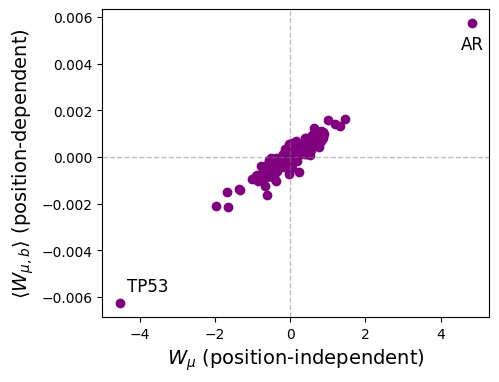

In [6]:
plt.figure(figsize=(5, 4))
x = mean_pi
y = np.mean(mean_pd, axis=1)

plt.scatter(x, y, color='purple')

# Find AR and TP53 indices
ar_idx = np.where(tfs == 'AR')[0][0]
tp53_idx = np.where(tfs == 'TP53')[0][0]

# Annotate AR and TP53
plt.annotate('AR', xy=(x[ar_idx], y[ar_idx]),
             xytext=(x[ar_idx] - 0.3, y[ar_idx] - 0.0011),
             fontsize=12)

plt.annotate('TP53', xy=(x[tp53_idx], y[tp53_idx]),
             xytext=(x[tp53_idx] + 0.2, y[tp53_idx] + 0.0005),
             fontsize=12
             )

plt.xlabel(r'$W_\mu$ (position-independent)', fontsize=14)
plt.ylabel(r'$\langle W_{\mu,b} \rangle$ (position-dependent)', fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.savefig(f'{FIGURES_DIR}/figS4_position_independent_vs_dependent_annotated.pdf', dpi=200, bbox_inches='tight')
plt.show()

## Fig. 5B -- Hierarchical clustering of spatial weight profiles, full heatmap + dendrogram


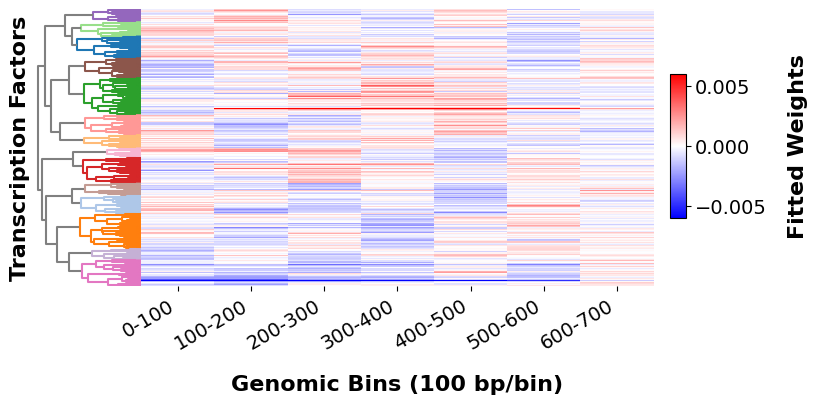

In [ ]:
import matplotlib.colors as mcolors

# --- 1. DATA PREP ---
df_clean = pd.DataFrame(mean_pd, columns=bin_cols)
df_clean['TF_Name'] = tfs
df_clean = df_clean.drop_duplicates(subset='TF_Name').set_index('TF_Name')

Z = linkage(df_clean[bin_cols], method='average', metric='correlation')
dn = dendrogram(Z, no_plot=True)
leaves_order = dn['leaves']
df_ordered = df_clean.iloc[leaves_order].copy()

N_CLUSTERS = 14
cluster_model = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='correlation', linkage='average')
df_clean['cluster'] = cluster_model.fit_predict(df_clean[bin_cols])
df_ordered['cluster'] = df_clean.loc[df_ordered.index, 'cluster']

# --- 2. COLOR SETUP ---
palette = sns.color_palette("tab20", N_CLUSTERS)
hex_palette = [mcolors.to_hex(c) for c in palette]
row_colors = [palette[int(c)] for c in df_ordered['cluster']]

def get_link_color(k):
    n = len(df_clean)
    if k < n:
        return hex_palette[int(df_clean.iloc[k]['cluster'])]
    left, right = Z[k - n, 0], Z[k - n, 1]
    c_left = get_link_color(int(left))
    c_right = get_link_color(int(right))
    return c_left if c_left == c_right else '#808080'

# --- 3. PLOTTING ---
fig = plt.figure(figsize=(8, 3.6))
gs = gridspec.GridSpec(1, 3, width_ratios=[2, 0.1, 10], wspace=0.0)

# A. DENDROGRAM
ax_dendro = plt.subplot(gs[0])
dendrogram(Z, ax=ax_dendro, orientation='left',
           link_color_func=get_link_color, color_threshold=0,
           no_labels=True)
ax_dendro.invert_yaxis()
ax_dendro.axis('off')

# B. COLOR STRIP
ax_color = plt.subplot(gs[1])
color_array = np.array([row_colors]).reshape(len(row_colors), 1, 3)
ax_color.imshow(color_array, aspect='auto', origin='upper')
ax_color.axis('off')

# C. HEATMAP
vmin, vmax = -0.006, 0.006
ax_heatmap = plt.subplot(gs[2])
sns.heatmap(df_ordered[bin_cols],
            ax=ax_heatmap,
            cmap='bwr',
            center=0, vmin=vmin, vmax=vmax,
            cbar=False,
            xticklabels=True,
            yticklabels=False)

ax_heatmap.set_ylabel('Transcription Factors', fontsize=16, fontweight='bold', labelpad=80)
ax_heatmap.set_xlabel('Genomic Bins (100 bp/bin)', fontsize=16, fontweight='bold', labelpad=15)
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(),
                           rotation=30,
                           ha='right',
                           fontsize=14,
                           fontweight='normal')

# D. COLORBAR
cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, cax=cbar_ax)

cbar.set_label('Fitted Weights', fontsize=16, fontweight='bold', labelpad=15)
cbar.ax.tick_params(labelsize=14)

fig.savefig(f'{FIGURES_DIR}/fig5b_spatial_clustering_heatmap.pdf', dpi=300, bbox_inches='tight')

plt.show()

## Fig. 5C -- Representative TF weight profiles per cluster (two per cluster: closest to
## centroid, and highest absolute weight), split into two panels for readability


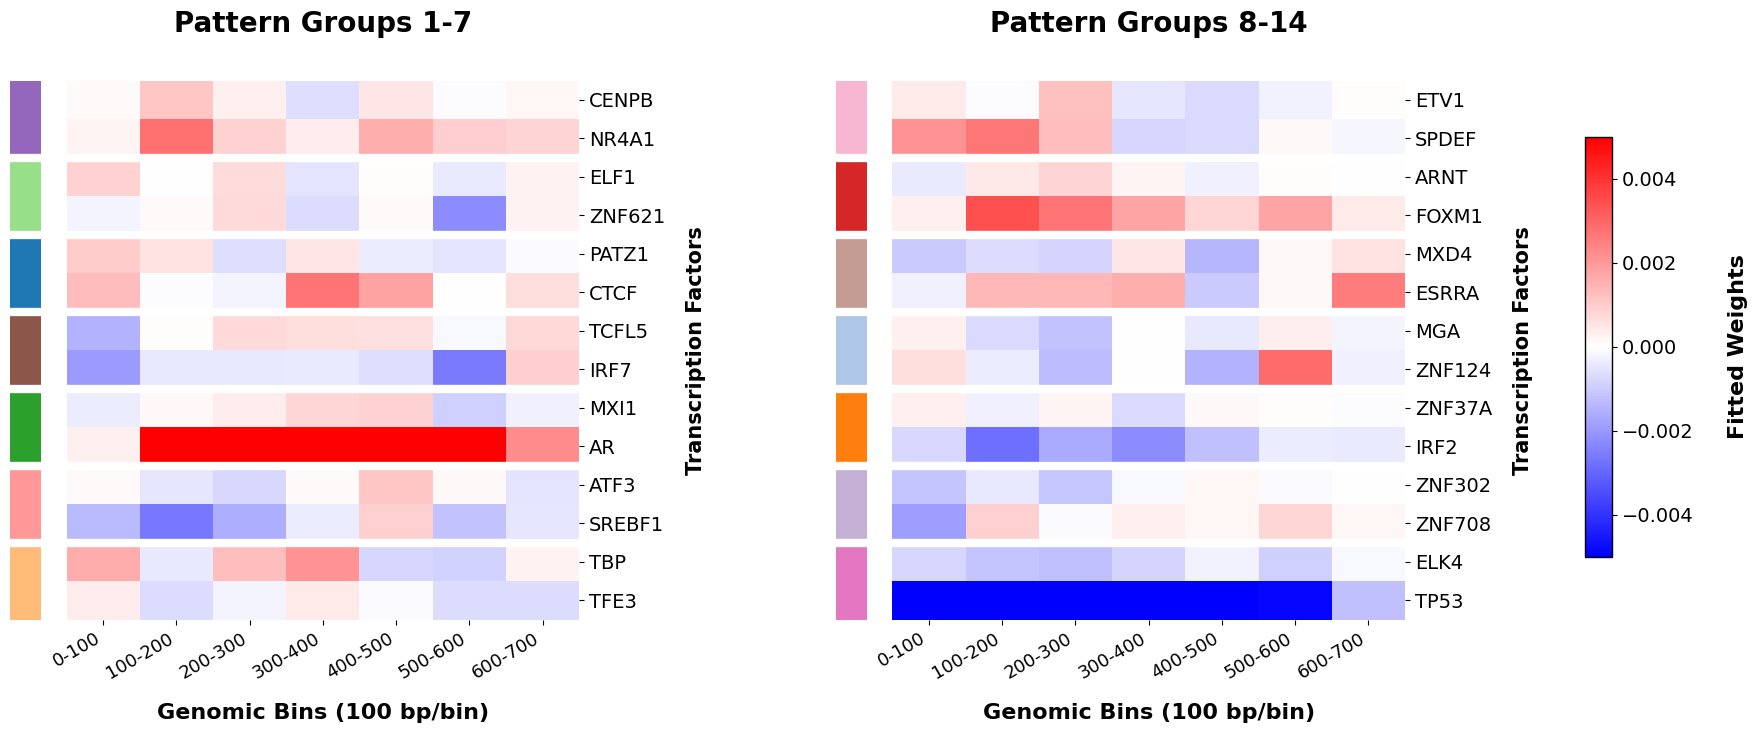

In [ ]:
# --- 1. DATA PREP (Standard) ---
df_clean = pd.DataFrame(mean_pd, columns=bin_cols)
df_clean['TF_Name'] = tfs
df_clean = df_clean.drop_duplicates(subset='TF_Name').set_index('TF_Name')

Z = linkage(df_clean[bin_cols], method='average', metric='correlation')
dn = dendrogram(Z, no_plot=True)
tree_order_tfs = df_clean.index[dn['leaves']].tolist()

n_clusters = 14
cluster_model = AgglomerativeClustering(n_clusters=n_clusters, metric='correlation', linkage='average')
df_clean['cluster'] = cluster_model.fit_predict(df_clean[bin_cols])
df_clean['strength'] = df_clean[bin_cols].abs().max(axis=1)

cluster_order = []
for tf in tree_order_tfs:
    c_id = df_clean.loc[tf, 'cluster']
    if c_id not in cluster_order:
        cluster_order.append(c_id)

selected_indices = []
for i in cluster_order:
    cluster_subset = df_clean[df_clean['cluster'] == i]

    # 1. Calculate the Centroid (Average Vector) of the cluster
    centroid_vector = cluster_subset[bin_cols].mean(axis=0).values.reshape(1, -1)

    # 2. Find the TF closest to the Centroid
    distances_to_centroid = cdist(centroid_vector, cluster_subset[bin_cols].values, metric='euclidean').flatten()
    closest_to_centroid_name = cluster_subset.index[np.argsort(distances_to_centroid)[0]]

    if len(cluster_subset) >= 2:
        # 3. Find the TF with the maximum absolute value (Max Strength)
        max_abs_tf_name = cluster_subset.sort_values('strength', ascending=False).index[0]

        # Handle edge case: if the closest to centroid IS the max-strength TF,
        # pick the second closest to the centroid so we have two unique TFs.
        if closest_to_centroid_name == max_abs_tf_name:
            closest_to_centroid_name = cluster_subset.index[np.argsort(distances_to_centroid)[1]]

        # Order: 1st row = Closest to Centroid, 2nd row = Max Absolute Value
        selected_indices.extend([closest_to_centroid_name, max_abs_tf_name])
    else:
        # If only one TF exists in the cluster, just add it
        selected_indices.extend(cluster_subset.index.tolist())

final_df = df_clean.loc[selected_indices].copy()
final_df['cluster'] = pd.Categorical(final_df['cluster'], categories=cluster_order, ordered=True)
final_df = final_df.sort_values('cluster')

df_part1 = final_df[final_df['cluster'].isin(cluster_order[:7])]
df_part2 = final_df[final_df['cluster'].isin(cluster_order[7:])]

# --- 2. SEABORN PLOTTING ---
palette = sns.color_palette("tab20", n_clusters)
fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(1, 5, width_ratios=[0.6, 10, 4.0, 0.6, 10], wspace=0.1)


vmin, vmax = -0.005, 0.005
def plot_panel(target_df, ax_color, ax_heat, title):
    # 1. Color Strip (Best kept as imshow/heatmap with no labels)
    cluster_ids = target_df['cluster'].astype(int).values
    color_data = np.array([[palette[c] for c in cluster_ids]]).reshape(len(cluster_ids), 1, 3)
    ax_color.imshow(color_data, aspect='auto')
    ax_color.set_axis_off()

    # 2. Main Heatmap (Now using SEABORN)
    sns.heatmap(target_df[bin_cols],
                ax=ax_heat,
                cmap='bwr',
                center=0, vmin=vmin, vmax=vmax,
                cbar=False,         # We draw our own custom one later
                xticklabels=True,
                yticklabels=True)   # Use the index (TF Names)

    # --- CUSTOMIZING SEABORN AXIS ---
    # Move Y-axis labels to the RIGHT
    ax_heat.yaxis.tick_right()
    ax_heat.yaxis.set_label_position("right")

    # Format Labels (Rotations and Font Sizes)
    ax_heat.set_ylabel('')  # Remove "TF_Name" label
    ax_heat.set_xlabel('')

    # Force tick formatting
    ax_heat.tick_params(axis='x', rotation=30, labelsize=13)
    ax_heat.set_ylabel('Transcription Factors', fontsize=15, fontweight='bold', labelpad=15)
    ax_heat.yaxis.set_label_position("right")  # Moves the label to the right of the names

    # Important: Set bold specifically for X-tick labels
    for label in ax_heat.get_xticklabels():
        label.set_ha('right')

    ax_heat.tick_params(axis='y', rotation=0, labelsize=14)

    # --- WIDE WHITE SEPARATORS ---
    num_rows = len(target_df)
    for i in range(2, num_rows, 2):
        ax_heat.axhline(y=i, color='white', linewidth=6, zorder=10)
        ax_color.axhline(y=i - 0.5, color='white', linewidth=6, zorder=10)  # imshow aligns slightly differently (center vs edge)

    ax_heat.set_title(title, fontsize=20, fontweight='bold', pad=35)

    ax_heat.set_xlabel('Genomic Bins (100 bp/bin)', fontsize=16, fontweight='bold', labelpad=15)

# Draw Panels
ax_c1, ax_h1 = plt.subplot(gs[0]), plt.subplot(gs[1])
plot_panel(df_part1, ax_c1, ax_h1, "Pattern Groups 1-7")

ax_c2, ax_h2 = plt.subplot(gs[3]), plt.subplot(gs[4])
plot_panel(df_part2, ax_c2, ax_h2, "Pattern Groups 8-14")

# --- COLORBAR SETTINGS ---
cbar_ax = fig.add_axes([1, 0.2, 0.015, 0.6])
sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Fitted Weights', fontsize=16, fontweight='bold', labelpad=25)
cbar.ax.tick_params(labelsize=14)
cbar.outline.set_linewidth(1)

fig.savefig(f'{FIGURES_DIR}/fig5c_representative_tf_profiles.pdf', dpi=300, bbox_inches='tight')

plt.show()